In [112]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [113]:
df1=pd.read_csv(r"C:\Users\anant\Downloads\archive (1)\train.csv")
df2=pd.read_csv(r"C:\Users\anant\Downloads\archive (1)\test.csv")

In [114]:
df = pd.concat([df1, df2])
df

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range,id
0,842,0,2.2,0,1,0,7,0.6,188,2,...,756,2549,9,7,19,0,0,1,1.0,NaN
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,1988,2631,17,3,7,1,1,0,2.0,NaN
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1716,2603,11,2,9,1,1,0,2.0,NaN
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1786,2769,16,8,11,1,0,0,2.0,NaN
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1212,1411,8,2,15,1,1,0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1700,1,1.9,0,0,1,54,0.5,170,7,...,913,2121,14,8,15,1,1,0,NaN,996.0
996,609,0,1.8,1,0,0,13,0.9,186,4,...,1632,1933,8,1,19,0,1,1,NaN,997.0
997,1185,0,1.4,0,1,1,8,0.5,80,1,...,825,1223,5,0,14,1,0,0,NaN,998.0
998,1533,1,0.5,1,0,0,50,0.4,171,2,...,832,2509,15,11,6,0,1,0,NaN,999.0


In [115]:
# i want to predict the price of mobile phone according to the spec

In [116]:
print(df.shape)


(3000, 22)


In [117]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  3000 non-null   int64  
 1   blue           3000 non-null   int64  
 2   clock_speed    3000 non-null   float64
 3   dual_sim       3000 non-null   int64  
 4   fc             3000 non-null   int64  
 5   four_g         3000 non-null   int64  
 6   int_memory     3000 non-null   int64  
 7   m_dep          3000 non-null   float64
 8   mobile_wt      3000 non-null   int64  
 9   n_cores        3000 non-null   int64  
 10  pc             3000 non-null   int64  
 11  px_height      3000 non-null   int64  
 12  px_width       3000 non-null   int64  
 13  ram            3000 non-null   int64  
 14  sc_h           3000 non-null   int64  
 15  sc_w           3000 non-null   int64  
 16  talk_time      3000 non-null   int64  
 17  three_g        3000 non-null   int64  
 18  touch_screen  

In [118]:
# Summary statistics
print(df.describe())


       battery_power         blue  clock_speed     dual_sim           fc  \
count    3000.000000  3000.000000  3000.000000  3000.000000  3000.000000   
mean     1241.849000     0.502000     1.528467     0.512000     4.404000   
std       437.063804     0.500079     0.820358     0.499939     4.383742   
min       500.000000     0.000000     0.500000     0.000000     0.000000   
25%       863.750000     0.000000     0.700000     0.000000     1.000000   
50%      1232.000000     1.000000     1.500000     1.000000     3.000000   
75%      1619.000000     1.000000     2.300000     1.000000     7.000000   
max      1999.000000     1.000000     3.000000     1.000000    19.000000   

            four_g   int_memory        m_dep    mobile_wt      n_cores  ...  \
count  3000.000000  3000.000000  3000.000000  3000.000000  3000.000000  ...   
mean      0.510000    32.581667     0.507000   140.003000     4.456333  ...   
std       0.499983    18.152810     0.285969    35.213809     2.289361  ...   

In [119]:
# Check missing values
print(df.isnull().sum())

battery_power       0
blue                0
clock_speed         0
dual_sim            0
fc                  0
four_g              0
int_memory          0
m_dep               0
mobile_wt           0
n_cores             0
pc                  0
px_height           0
px_width            0
ram                 0
sc_h                0
sc_w                0
talk_time           0
three_g             0
touch_screen        0
wifi                0
price_range      1000
id               2000
dtype: int64


In [120]:
# we need to handle missing values

In [121]:
print(df.duplicated().sum())

0


In [122]:
#we need to check the numerical and catogorical columns

In [123]:
import matplotlib.pyplot as plt
import seaborn as sns

# Numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

# Categorical columns
cat_cols = df.select_dtypes(include=['object']).columns


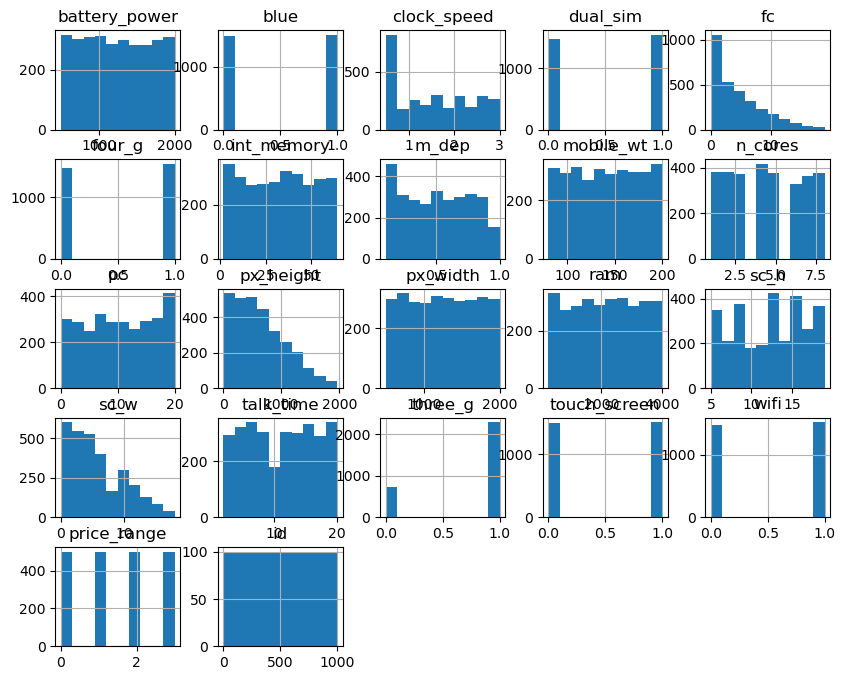

In [124]:
df[num_cols].hist(figsize=(10, 8))
plt.show()

In [125]:
cat_cols

Index([], dtype='object')

In [126]:
#no catogorical

In [127]:
# Fill missing values
df['price_range'].fillna(df['price_range'].mean(), inplace=True)     # for numerical

C:\Users\anant\AppData\Local\Temp\ipykernel_19760\434798891.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['price_range'].fillna(df['price_range'].mean(), inplace=True)     # for numerical


In [128]:
#visualize relationships between these features (especially the ones more correlated with price_range), 
#you can make a pair plot for the top correlated columns.

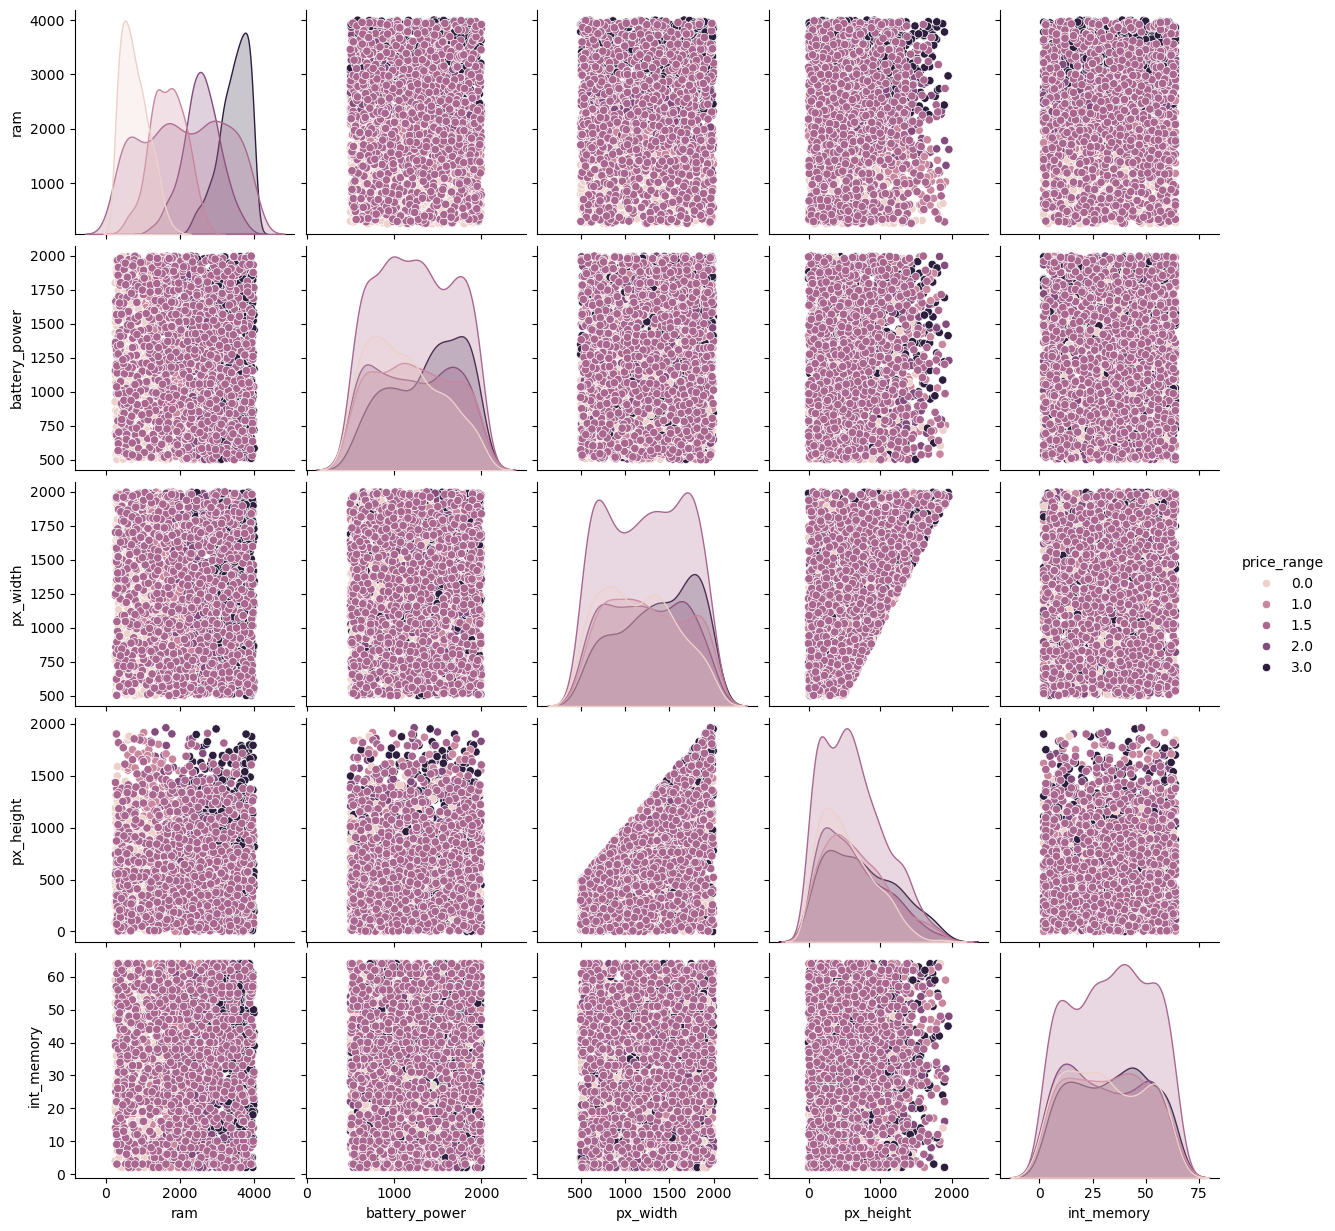

In [129]:
selected_cols = ['price_range', 'ram', 'battery_power', 'px_width', 'px_height', 'int_memory']

# Create pair plot
sns.pairplot(df[selected_cols], hue='price_range', diag_kind='kde')

plt.show()

In [130]:
# Correlation with target
correlation = df.corr()['price_range'].sort_values(ascending=False)
print(correlation)


price_range      1.000000
ram              0.748039
battery_power    0.164758
px_width         0.134610
px_height        0.122519
int_memory       0.036264
sc_w             0.031853
pc               0.027388
three_g          0.019228
sc_h             0.018599
talk_time        0.017812
fc               0.017787
blue             0.016797
wifi             0.015338
dual_sim         0.014245
four_g           0.012052
n_cores          0.003589
m_dep            0.000702
clock_speed     -0.005364
touch_screen    -0.024830
mobile_wt       -0.024870
id                    NaN
Name: price_range, dtype: float64


In [131]:
# from this i classify the target and independent variables

In [132]:
#target:-price_range
#independent variables:-ram,clock_speed,touch_screen,int_memory 

In [143]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()      # or MinMaxScaler()
df_scaled = scaler.fit_transform(df)

# Convert back to DataFrame
df_scaled = pd.DataFrame(df_scaled, columns=df.columns)


In [145]:
#splitting data  for testing and training

In [147]:
import pandas as pd
from sklearn.model_selection import train_test_split


In [149]:
# Assuming your dataset is called df
X = df[['ram', 'battery_power', 'px_width', 'px_height', 'int_memory']]
y = df['price_range']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Check the shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2400, 5)
X_test shape: (600, 5)
y_train shape: (2400,)
y_test shape: (600,)


In [151]:
# applying leniar regression model

In [153]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [155]:
# Initialize model
lr = LinearRegression()

# Train model
lr.fit(X_train, y_train)


LinearRegression()

In [157]:
# Predict on test set
y_pred = lr.predict(X_test)


In [159]:
# Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)
# R-squared
r2 = r2_score(y_test, y_pred)
print("R-squared:", r2)

Mean Squared Error: 0.3027562774107342
R-squared: 0.636692467107119


In [161]:
import numpy as np
rmse = np.sqrt(0.3543)
print("RMSE:", rmse)


RMSE: 0.5952310475773253


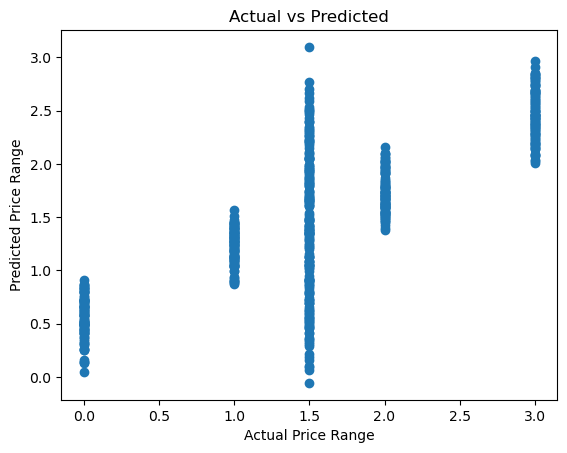

In [163]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price Range")
plt.ylabel("Predicted Price Range")
plt.title("Actual vs Predicted")
plt.show()


In [165]:
#price_range is categorical/discrete (0,1,2,3), using Linear Regression isn’t ideal. Instead, we can use a classification model.

In [167]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score


In [171]:
# Features
X = df[['ram', 'battery_power', 'px_width', 'px_height', 'int_memory']]

# Target
y = df['price_range']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [173]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)



In [185]:
# alpha = regularization strength (higher alpha = more regularization)
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train, y_train)


Lasso(alpha=0.1, max_iter=10000)

In [187]:
y_pred = lasso.predict(X_test)


In [189]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

# Check coefficients
coeff_df = pd.DataFrame({
    'Feature': ['ram', 'clock_speed', 'touch_screen', 'int_memory'],
    'Coefficient': lasso.coef_
})
print(coeff_df)


Mean Squared Error: 0.36166773429835625
R-squared: 0.5932051578827726


ValueError: All arrays must be of the same length

In [191]:
#Both the model predict the same output

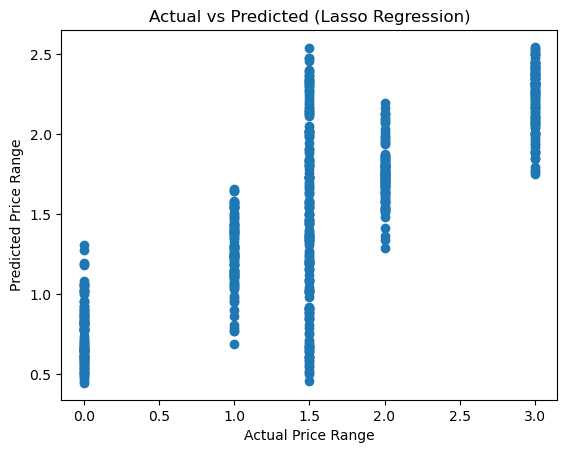

In [193]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price Range")
plt.ylabel("Predicted Price Range")
plt.title("Actual vs Predicted (Lasso Regression)")
plt.show()


In [195]:
#same in lasso and liner reg

In [ ]:
#check overfitting

In [ ]:
y_train_pred = lasso.predict(X_train)
y_test_pred = lasso.predict(X_test)

In [ ]:
# Mean Squared Error
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)

# R-squared
r2_train = r2_score(y_train, y_train_pred 
r2_test = r2_score(y_test, y_test_pred)

print("Training MSE:", mse_train)
print("Test MSE:", mse_test)
print("Training R2:", r2_train)
print("Test R2:", r2_test)


In [ ]:
#no overfitting and no underfitting